# EstateX Advisor - Real Estate EDA

**Dataset:** Saudi Arabia Real Estate Transactions (2020-2025)  
**Purpose:** Comprehensive analysis for valuation, prediction & recommendation system  

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Data Overview & Quality](#2)
3. [Market Trends Analysis](#3)
4. [Property Type Analysis](#4)
5. [Geographic Analysis](#5)
6. [Investment Indicators](#6)


---

<a id='1'></a>
## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)



In [3]:
# Load data
df = pd.read_excel('/Users/aljawharah/EstateX-Roshn-Hackathon/dataset/Real Estate Data.xlsx')

# Ensure proper data types
df['date'] = pd.to_datetime(df['date'])
df['year_quarter'] = df['year'].astype(str) + '-' + df['quarter'].str[-2:]

# Basic dataset info
print(f"  • Total transactions: {len(df):,}")
print(f"  • Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  • Columns: {len(df.columns)}")

  • Total transactions: 138,557
  • Date range: 2020-07-01 to 2025-03-30
  • Columns: 14


In [4]:
df.head()

,region,city,transaction_id,property_class,property_count,property_type,district,price_sar,area_sqm,price_per_sqm,date,year,quarter,year_quarter
0,منطقة الرياض,الرياض,27048618,سكني,1,NaN,الزهراء,1800000,348.75,5161.290323,2025-01-01,2025,2025Q1,2025-Q1
1,منطقة الرياض,الرياض,27047908,سكني,1,NaN,الدريهمية,687664,156.63,4390.372215,2025-01-01,2025,2025Q1,2025-Q1
2,منطقة الرياض,الرياض,27049909,سكني,1,NaN,بدر,1300000,600.00,2166.666667,2025-01-01,2025,2025Q1,2025-Q1
3,منطقة الرياض,الرياض,27050165,سكني,1,NaN,بدر,450000,146.40,3073.770492,2025-01-01,2025,2025Q1,2025-Q1
4,منطقة الرياض,الرياض,27047395,سكني,1,NaN,الزهراء,3187592,326.65,9758.432573,2025-01-01,2025,2025Q1,2025-Q1


In [5]:
df.tail()

,region,city,transaction_id,property_class,property_count,property_type,district,price_sar,area_sqm,price_per_sqm,date,year,quarter,year_quarter
138552,منطقة الرياض,الرياض,19679611,زراعي,1,شقة,حطين,950000,158.33,6000.1263,2023-03-31,2023,2023Q1,2023-Q1
138553,منطقة الرياض,الرياض,19679658,سكني,1,قطعة أرض,عريض,200000,450.00,444.4444,2023-03-31,2023,2023Q1,2023-Q1
138554,منطقة الرياض,الرياض,19679702,سكني,1,قطعة أرض,عكاظ,805012,587.60,1370.0000,2023-03-31,2023,2023Q1,2023-Q1
138555,منطقة الرياض,الرياض,19679089,سكني,1,قطعة أرض,لبن,1500000,450.00,3333.3333,2023-03-31,2023,2023Q1,2023-Q1
138556,منطقة الرياض,الرياض,19679797,سكني,1,قطعة أرض,نمار,700000,750.00,933.3333,2023-03-31,2023,2023Q1,2023-Q1


<a id='2'></a>
## 2. Data Overview & Quality

In [7]:
# Dataset structure
print(f"  • Rows: {df.shape[0]:,}")
print(f"  • Columns: {df.shape[1]}")

df.info()

  • Rows: 138,557
  • Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138557 entries, 0 to 138556
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   region          138557 non-null  object        
 1   city            138557 non-null  object        
 2   transaction_id  138557 non-null  int64         
 3   property_class  138557 non-null  object        
 4   property_count  138557 non-null  int64         
 5   property_type   23386 non-null   object        
 6   district        138557 non-null  object        
 7   price_sar       138557 non-null  int64         
 8   area_sqm        138557 non-null  float64       
 9   price_per_sqm   138557 non-null  float64       
 10  date            138557 non-null  datetime64[ns]
 11  year            138557 non-null  int64         
 12  quarter         138557 non-null  object        
 13  year_quarter    138557 non-null  object        
dtypes:

In [8]:
# Missing values check
df.isnull().sum()

region                 0
city                   0
transaction_id         0
property_class         0
property_count         0
property_type     115171
district               0
price_sar              0
area_sqm               0
price_per_sqm          0
date                   0
year                   0
quarter                0
year_quarter           0
dtype: int64

In [9]:
# property_type اـ"Unknown"
df['property_type'] = df['property_type'].fillna('Unknown')

df['district'] = df['district'].fillna('Unknown')

print(" Missing values filled with 'Unknown'")
print(f"\nProperty types now:")
#عد الانواع
print(df['property_type'].value_counts())

 Missing values filled with 'Unknown'

Property types now:
property_type
Unknown       115171
قطعة أرض       18841
شقة             4318
بيت               94
فيلا              50
معرض/محل          47
عمارة             19
مرفق              10
أرض زراعية         3
مركز تجاري         3
إستراحة            1
Name: count, dtype: int64


In [10]:
# Basic statistics
print(" NUMERIC STATISTICS:")
df[['price_sar', 'area_sqm', 'price_per_sqm']].describe()

 NUMERIC STATISTICS:


,price_sar,area_sqm,price_per_sqm
count,1.385570e+05,1.385570e+05,138557.000000
mean,1.586659e+06,1.161148e+03,2449.719639
std,1.091106e+07,2.911843e+04,2955.241139
min,5.000000e+03,1.219200e+00,1.116700
25%,3.483000e+05,3.000000e+02,716.049300
50%,6.400000e+05,4.200000e+02,1515.151515
75%,1.150000e+06,7.500000e+02,3266.666667
max,1.745440e+09,5.414613e+06,186668.157778


In [11]:
# Data quality checks

# Duplicates
duplicates = df.duplicated(subset=['transaction_id']).sum()
print(f"Duplicate transaction IDs: {duplicates:,}")

# Invalid values
print(f"Invalid prices (≤0): {(df['price_sar'] <= 0).sum():,}")
print(f"Invalid areas (≤0): {(df['area_sqm'] <= 0).sum():,}")
print(f"Tiny properties (<10 sqm): {(df['area_sqm'] < 10).sum():,}")
print(f"Huge properties (>100K sqm): {(df['area_sqm'] > 100000).sum():,}")

Duplicate transaction IDs: 0
Invalid prices (≤0): 0
Invalid areas (≤0): 0
Tiny properties (<10 sqm): 16
Huge properties (>100K sqm): 108


 PROPERTY CLASS DISTRIBUTION:

سكني: 121,841 (87.9%)
تجاري: 13,313 (9.6%)
زراعي: 3,402 (2.5%)
صناعي: 1 (0.0%)


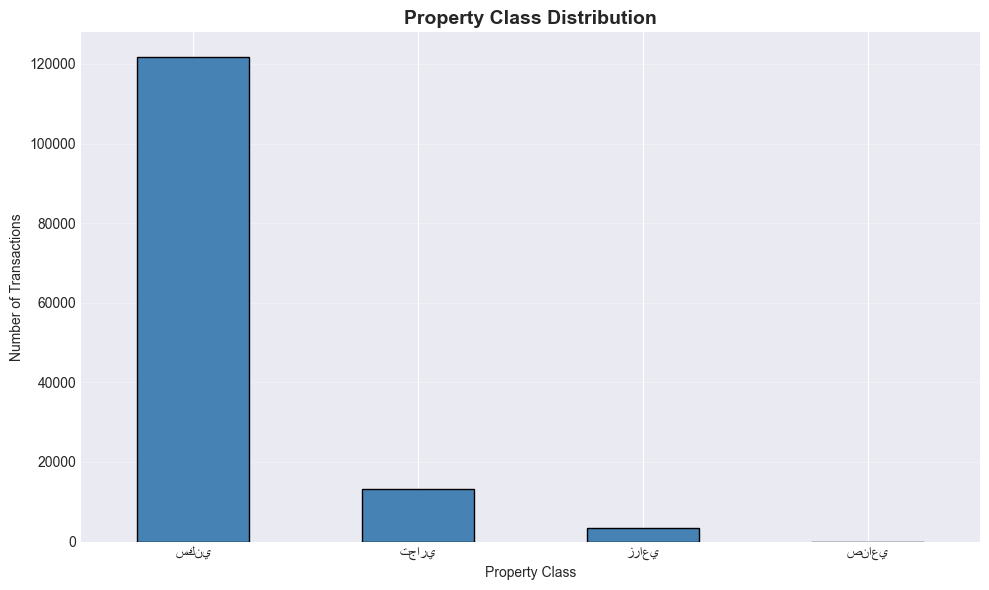

In [12]:
# Property class distribution
print(" PROPERTY CLASS DISTRIBUTION:\n")
prop_dist = df['property_class'].value_counts()
for prop_class, count in prop_dist.items():
    pct = (count / len(df)) * 100
    print(f"{prop_class}: {count:,} ({pct:.1f}%)")

# Visualization
plt.figure(figsize=(10, 6))
prop_dist.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Property Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Number of Transactions')
plt.xlabel('Property Class')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Outlier detection (IQR method)
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return len(outliers), (len(outliers) / len(df)) * 100, lower, upper

print(" OUTLIER DETECTION:\n")
for col in ['price_sar', 'area_sqm', 'price_per_sqm']:
    count, pct, lower, upper = detect_outliers(col)
    print(f"{col}:")
    print(f"  Outliers: {count:,} ({pct:.2f}%)")
    print(f"  Bounds: [{lower:,.0f}, {upper:,.0f}]\n")

 OUTLIER DETECTION:

price_sar:
  Outliers: 13,738 (9.92%)
  Bounds: [-854,250, 2,352,550]

area_sqm:
  Outliers: 8,375 (6.04%)
  Bounds: [-375, 1,425]

price_per_sqm:
  Outliers: 8,136 (5.87%)
  Bounds: [-3,110, 7,093]



 الاستنتاجات الرئيسية
توزيع أنواع العقارات:
يكشف الداتاست أن سوق العقارات في الرياض يهيمن عليه بشكل كبير العقارات السكنية، حيث تشكل نحو 88% من جميع الصفقات. تمثل العقارات التجارية حوالي 10% من السوق، في حين تشكل الأراضي الزراعية نسبة صغيرة لكنها ملحوظة تبلغ 2.5%. أما العقارات الصناعية فهي تكاد تكون معدومة مع صفقة واحدة فقط، مما يجعلها غير مهمة إحصائيًا للتحليل.
تحليل النقاط الشاذة:
حوالي 10% من العقارات تقع خارج نطاق الأسعار الطبيعية، و6% لها مساحات غير معتادة، وما يقرب من 6% تظهر قيم سعر لكل متر مربع شاذة. هذه النقاط الشاذة ليست أخطاء بيانات، بل تمثل عقارات فاخرة حقيقية، مشاريع تجارية كبيرة، وأراضٍ زراعية ذات خصائص متطرفة. وجود حوالي 10% نقاط شاذة يُعد طبيعيًا ومتوقعًا في الأسواق العقارية التي تحتوي على عقارات عالية القيمة.

 ما الفائدة التي حصلنا عليها من هذا التحليل
فهم السوق:
ندرك الآن أن قاعدة المستخدمين الرئيسية ستكون مشترين وبائعي العقارات السكنية، ما يمثل تقريبًا 9 من كل 10 صفقات. هذه المعرفة تمكننا من توجيه الموارد بشكل صحيح وتصميم تجربة مستخدم مخصصة للمشترين، مع إمكانية خدمة المستخدمين المهتمين بالاستثمار أو العقارات التجارية.


<a id='3'></a>
## 3. Market Trends Analysis -- forcasting

In [15]:
# Quarterly statistics
quarterly = df.groupby('quarter').agg({
    'price_sar': ['median', 'mean', 'count'],
    'price_per_sqm': ['median', 'mean'],
    'area_sqm': 'median'
}).round(0)
quarterly.columns = ['Median_Price', 'Mean_Price', 'Volume', 
                     'Median_Price_sqm', 'Mean_Price_sqm', 'Median_Area']
quarterly = quarterly.sort_index()

print(" QUARTERLY TRENDS:")
quarterly

 QUARTERLY TRENDS:


,Median_Price,Mean_Price,Volume,Median_Price_sqm,Mean_Price_sqm,Median_Area
quarter,,,,,,
2020Q3,370000.0,949241.0,12127,800.0,1629.0,453.0
2020Q4,400000.0,994675.0,18942,684.0,1384.0,600.0
2021Q2,537751.0,1321575.0,15393,1111.0,1943.0,445.0
2021Q3,600000.0,1574822.0,14133,1250.0,2228.0,455.0
2022Q1,754000.0,1532276.0,11800,1533.0,2411.0,460.0
2022Q2,842179.0,1852876.0,1821,1600.0,2495.0,452.0
2022Q3,710000.0,1888395.0,10094,1625.0,2600.0,400.0
2022Q4,855000.0,2319672.0,8641,2267.0,3238.0,400.0
2023Q1,850000.0,1816761.0,9765,2518.0,3617.0,375.0


In [16]:
# Yearly statistics
yearly = df.groupby('year').agg({
    'price_sar': ['median', 'mean', 'count'],
    'price_per_sqm': ['median', 'mean']
}).round(0)
yearly.columns = ['Median_Price', 'Mean_Price', 'Volume', 
                  'Median_Price_sqm', 'Mean_Price_sqm']

print(" YEARLY TRENDS:")
yearly

 YEARLY TRENDS:


,Median_Price,Mean_Price,Volume,Median_Price_sqm,Mean_Price_sqm
year,,,,,
2020,400000.0,976941.0,31069,714.0,1479.0
2021,572628.0,1442795.0,29526,1198.0,2079.0
2022,780000.0,1871699.0,32356,1709.0,2696.0
2023,850000.0,1816761.0,9765,2518.0,3617.0
2024,693750.0,1704477.0,20216,1800.0,2926.0
2025,812500.0,2184392.0,15625,2300.0,3225.0


In [19]:
# Year-over-year growth
print("YEAR-OVER-YEAR GROWTH:\n")
for i in range(1, len(yearly)):
    prev_year = yearly.index[i-1]
    curr_year = yearly.index[i]
    
    price_growth = ((yearly.loc[curr_year, 'Median_Price'] - 
                    yearly.loc[prev_year, 'Median_Price']) / 
                   yearly.loc[prev_year, 'Median_Price'] * 100)
    
    volume_growth = ((yearly.loc[curr_year, 'Volume'] - 
                     yearly.loc[prev_year, 'Volume']) / 
                    yearly.loc[prev_year, 'Volume'] * 100)
    
    print(f"{prev_year} → {curr_year}:")
    print(f"  Price: {price_growth:+.1f}%")
    print(f"  Volume: {volume_growth:+.1f}%\n")

YEAR-OVER-YEAR GROWTH:

2020 → 2021:
  Price: +43.2%
  Volume: -5.0%

2021 → 2022:
  Price: +36.2%
  Volume: +9.6%

2022 → 2023:
  Price: +9.0%
  Volume: -69.8%

2023 → 2024:
  Price: -18.4%
  Volume: +107.0%

2024 → 2025:
  Price: +17.1%
  Volume: -22.7%



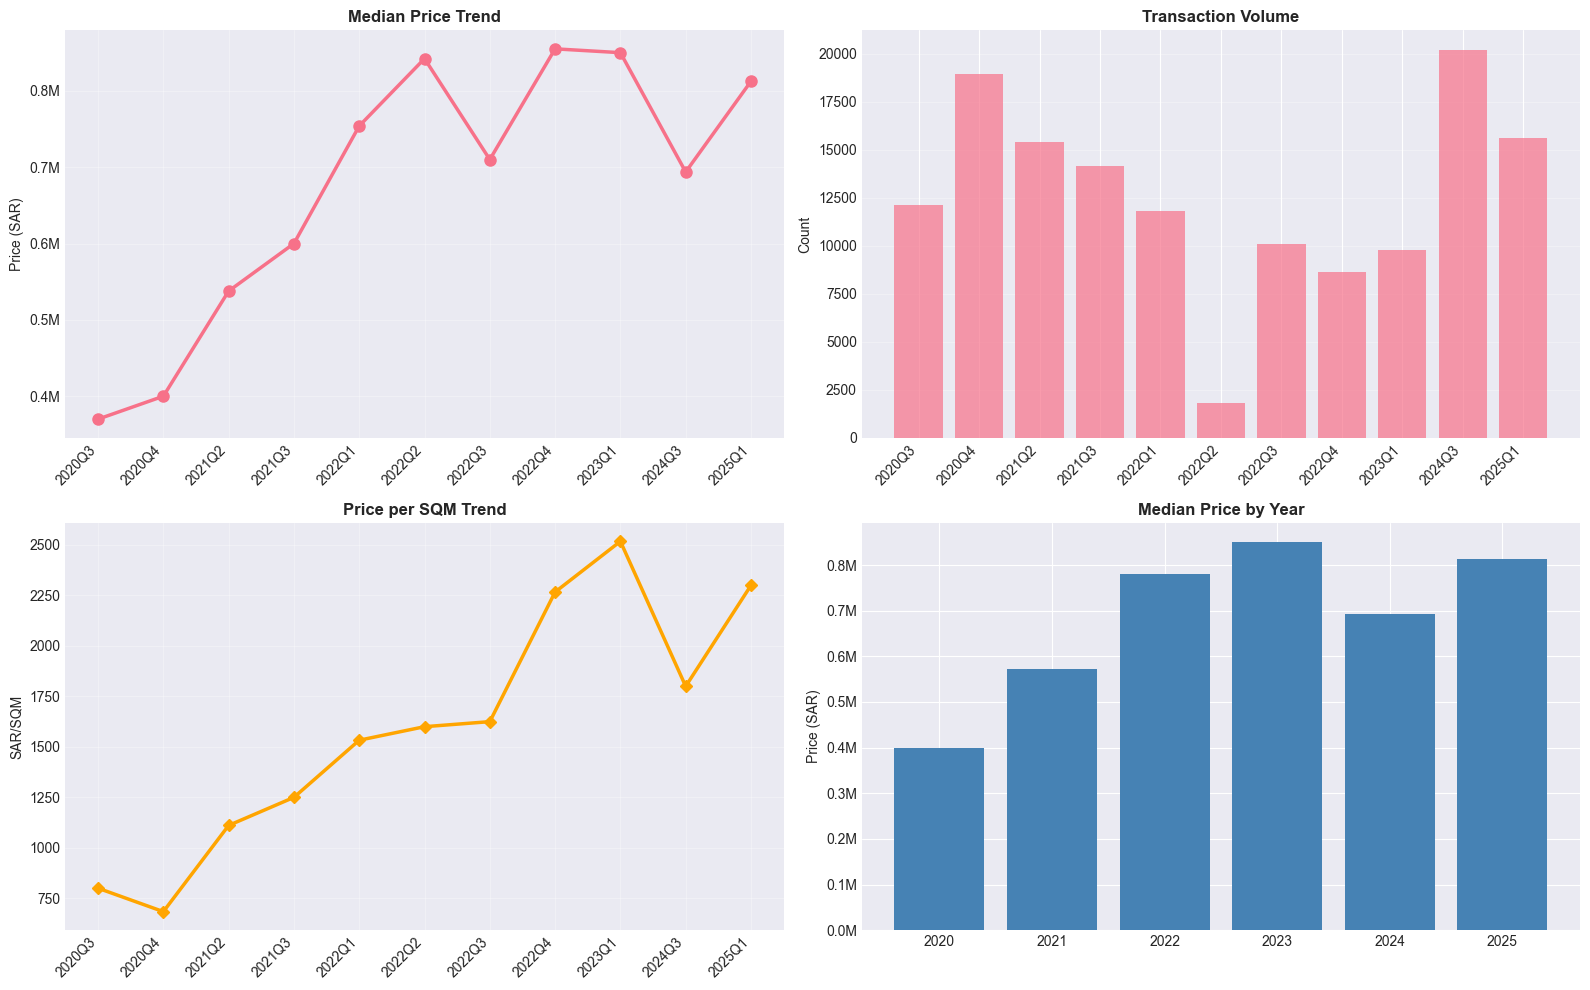

In [18]:
# Visualization: Market trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Price trend
ax = axes[0, 0]
ax.plot(range(len(quarterly)), quarterly['Median_Price'], 
        marker='o', linewidth=2.5, markersize=8)
ax.set_xticks(range(len(quarterly)))
ax.set_xticklabels(quarterly.index, rotation=45, ha='right')
ax.set_title('Median Price Trend', fontweight='bold')
ax.set_ylabel('Price (SAR)')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Plot 2: Volume trend
ax = axes[0, 1]
ax.bar(range(len(quarterly)), quarterly['Volume'], alpha=0.7)
ax.set_xticks(range(len(quarterly)))
ax.set_xticklabels(quarterly.index, rotation=45, ha='right')
ax.set_title('Transaction Volume', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Price per sqm
ax = axes[1, 0]
ax.plot(range(len(quarterly)), quarterly['Median_Price_sqm'], 
        marker='D', linewidth=2.5, color='orange')
ax.set_xticks(range(len(quarterly)))
ax.set_xticklabels(quarterly.index, rotation=45, ha='right')
ax.set_title('Price per SQM Trend', fontweight='bold')
ax.set_ylabel('SAR/SQM')
ax.grid(True, alpha=0.3)

# Plot 4: Yearly comparison
ax = axes[1, 1]
ax.bar(yearly.index, yearly['Median_Price'], color='steelblue')
ax.set_title('Median Price by Year', fontweight='bold')
ax.set_ylabel('Price (SAR)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. Property Type Analysis

In [20]:
# Performance by property class
print(" PERFORMANCE BY PROPERTY TYPE:\n")

for prop_class in df['property_class'].unique():
    subset = df[df['property_class'] == prop_class]
    print(f"{prop_class}:")
    print(f"  Transactions: {len(subset):,} ({len(subset)/len(df)*100:.1f}%)")
    print(f"  Median price: {subset['price_sar'].median():,.0f} SAR")
    print(f"  Median price/sqm: {subset['price_per_sqm'].median():,.0f} SAR/sqm")
    print(f"  Median area: {subset['area_sqm'].median():,.0f} sqm")
    
    # Growth calculation
    yearly_trend = subset.groupby('year')['price_per_sqm'].median()
    if len(yearly_trend) >= 2:
        first = yearly_trend.iloc[0]
        last = yearly_trend.iloc[-1]
        years = yearly_trend.index[-1] - yearly_trend.index[0]
        
        total_growth = ((last - first) / first) * 100
        cagr = ((last / first) ** (1/years) - 1) * 100 if years > 0 else 0
        
        print(f"  Total growth: {total_growth:+.1f}%")
        print(f"  CAGR: {cagr:+.1f}%")
    print()

 PERFORMANCE BY PROPERTY TYPE:

سكني:
  Transactions: 121,841 (87.9%)
  Median price: 599,000 SAR
  Median price/sqm: 1,418 SAR/sqm
  Median area: 405 sqm
  Total growth: +241.3%
  CAGR: +27.8%

تجاري:
  Transactions: 13,313 (9.6%)
  Median price: 1,680,000 SAR
  Median price/sqm: 2,000 SAR/sqm
  Median area: 900 sqm
  Total growth: +108.3%
  CAGR: +15.8%

زراعي:
  Transactions: 3,402 (2.5%)
  Median price: 893,050 SAR
  Median price/sqm: 6,496 SAR/sqm
  Median area: 136 sqm
  Total growth: +1096.9%
  CAGR: +64.3%

صناعي:
  Transactions: 1 (0.0%)
  Median price: 2,000,000 SAR
  Median price/sqm: 1,109 SAR/sqm
  Median area: 1,803 sqm



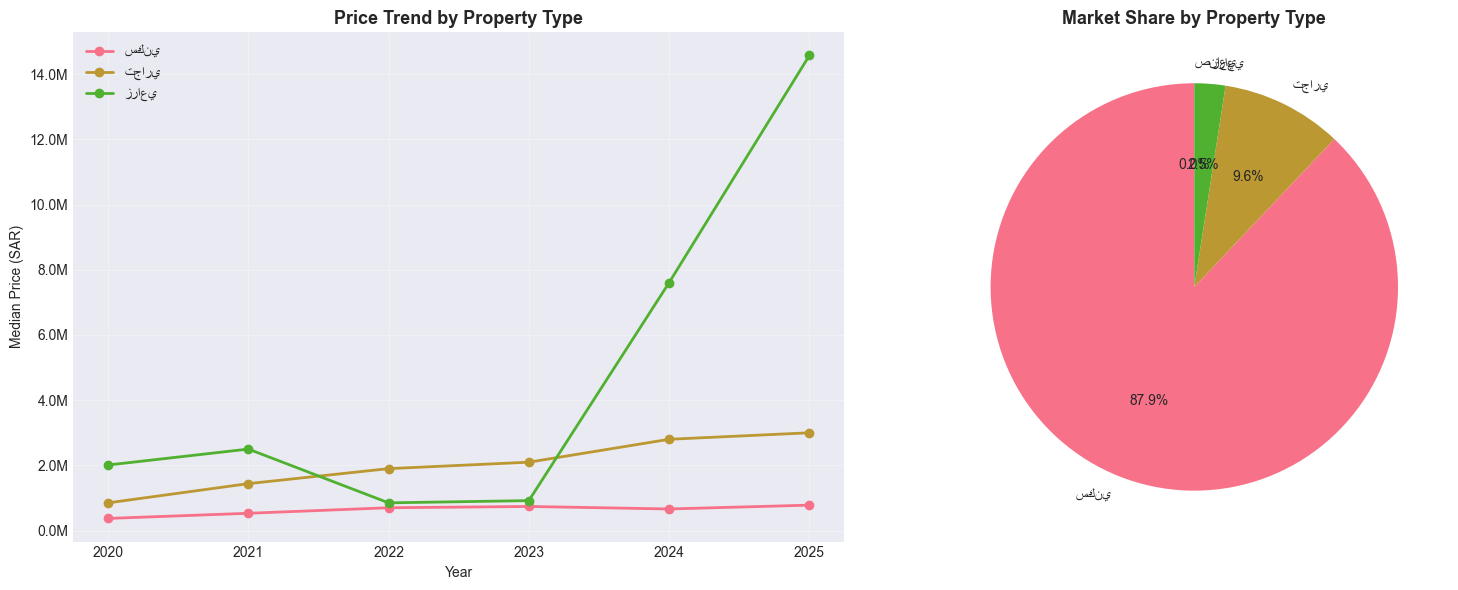

In [21]:
# Visualization: Property type comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price trends
ax = axes[0]
for prop_class in ['سكني', 'تجاري', 'زراعي']:
    if prop_class in df['property_class'].values:
        subset = df[df['property_class'] == prop_class]
        trend = subset.groupby('year')['price_sar'].median()
        ax.plot(trend.index, trend.values, marker='o', label=prop_class, linewidth=2)
ax.set_title('Price Trend by Property Type', fontweight='bold', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Median Price (SAR)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Market share
ax = axes[1]
market_share = df['property_class'].value_counts()
ax.pie(market_share.values, labels=market_share.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Market Share by Property Type', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. Geographic Analysis

In [22]:
# District statistics
district_stats = df.groupby('district').agg({
    'price_sar': ['median', 'mean'],
    'price_per_sqm': ['median', 'mean'],
    'transaction_id': 'count',
    'area_sqm': 'median'
}).round(0)
district_stats.columns = ['Median_Price', 'Mean_Price', 'Median_Price_sqm',
                          'Mean_Price_sqm', 'Volume', 'Median_Area']

print(f"Total districts analyzed: {len(district_stats)}")

Total districts analyzed: 208


In [23]:
# Top 15 most expensive
print(" TOP 15 MOST EXPENSIVE DISTRICTS:\n")
expensive = district_stats.nlargest(15, 'Median_Price')
expensive[['Median_Price', 'Median_Price_sqm', 'Volume']]

 TOP 15 MOST EXPENSIVE DISTRICTS:



,Median_Price,Median_Price_sqm,Volume
district,,,
العماجية,644332609.0,272.0,1
شمال شرق مدينة الرياض,286628832.0,57.0,1
جامعة الامام بن سعود الاسلامية,204111320.0,2000.0,1
الجوهرة,16471956.0,4600.0,1
ظهرة العودة,5400000.0,1800.0,1
المنصورية,4680000.0,1097.0,33
المؤتمرات,4450000.0,3224.0,4
الدرعية,3022615.0,240.0,1
صلاح الدين,2925000.0,4795.0,4


In [24]:
# Top 15 most active
print(" TOP 15 MOST ACTIVE DISTRICTS:\n")
active = district_stats.nlargest(15, 'Volume')
active[['Volume', 'Median_Price', 'Median_Price_sqm']]

 TOP 15 MOST ACTIVE DISTRICTS:



,Volume,Median_Price,Median_Price_sqm
district,,,
الخير,13973,510000.0,867.0
عريض,10617,260000.0,611.0
نمار,9134,600000.0,1040.0
الجنادرية,7866,338885.0,914.0
الرمال,6159,1020000.0,2333.0
شرق الرياض,5856,260000.0,325.0
النظيم,5573,456300.0,1300.0
النرجس,4140,1548500.0,5000.0
لبن,3540,662165.0,2500.0


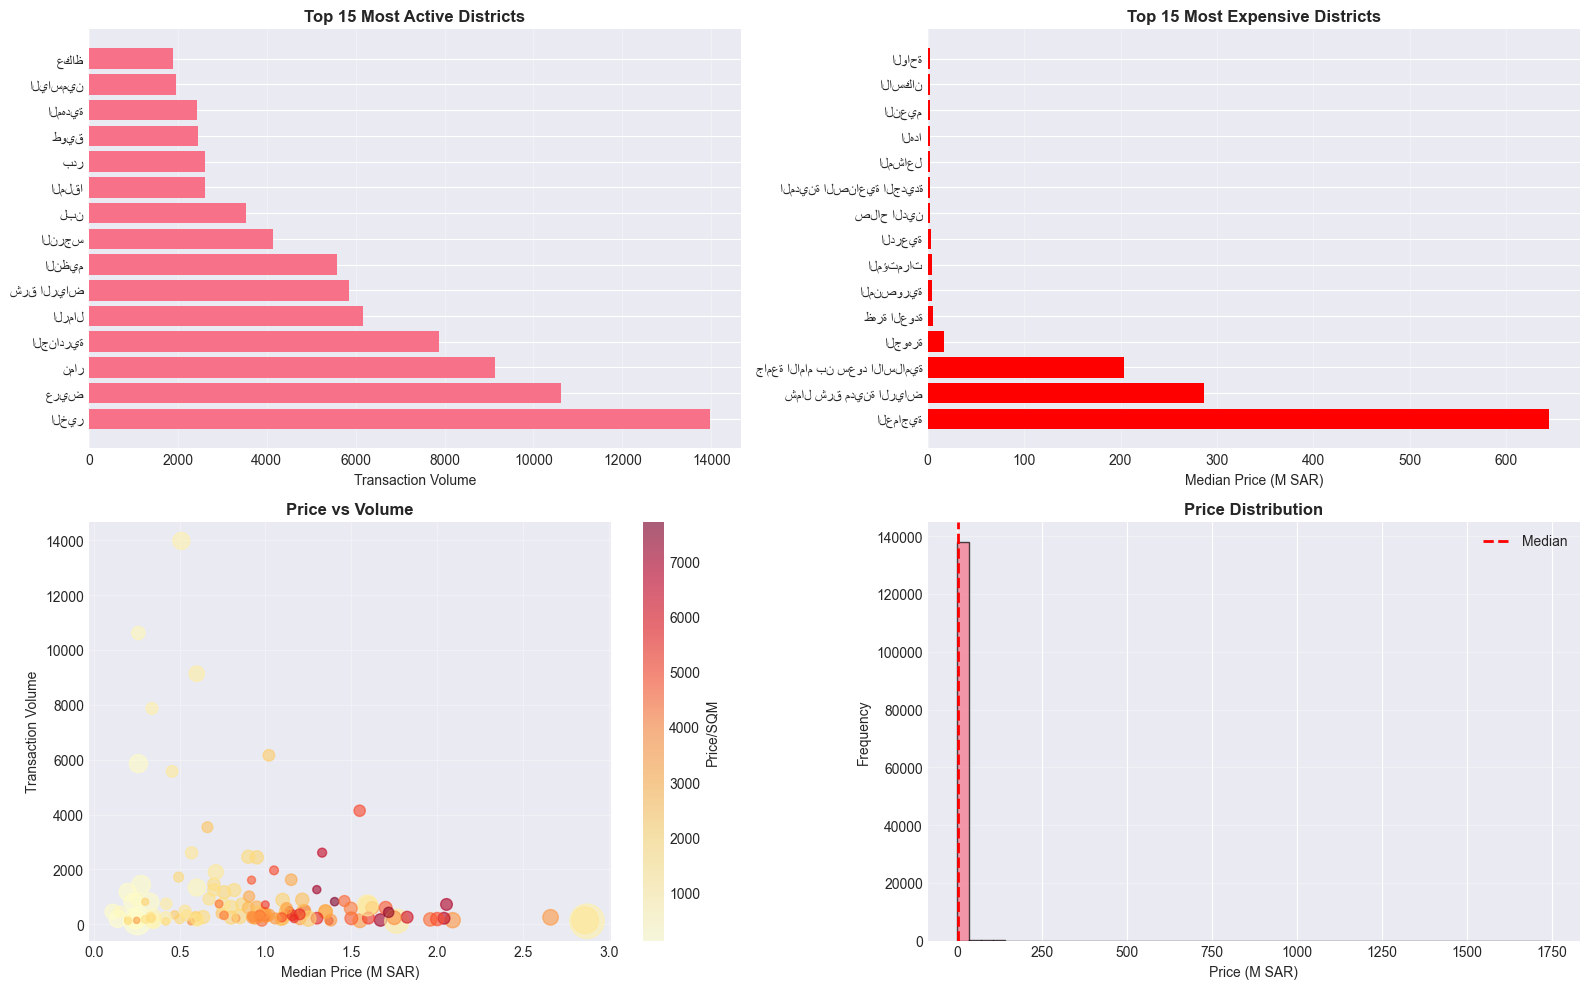

In [25]:
# Visualization: Geographic insights
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top districts by volume
ax = axes[0, 0]
top_volume = district_stats.nlargest(15, 'Volume')
ax.barh(range(len(top_volume)), top_volume['Volume'].values)
ax.set_yticks(range(len(top_volume)))
ax.set_yticklabels(top_volume.index)
ax.set_xlabel('Transaction Volume')
ax.set_title('Top 15 Most Active Districts', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Most expensive
ax = axes[0, 1]
top_price = district_stats.nlargest(15, 'Median_Price')
ax.barh(range(len(top_price)), top_price['Median_Price'].values/1e6, color='red')
ax.set_yticks(range(len(top_price)))
ax.set_yticklabels(top_price.index)
ax.set_xlabel('Median Price (M SAR)')
ax.set_title('Top 15 Most Expensive Districts', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Price vs Volume scatter
ax = axes[1, 0]
filtered = district_stats[district_stats['Volume'] >= 100]
scatter = ax.scatter(filtered['Median_Price']/1e6, filtered['Volume'],
                    s=filtered['Median_Area']/5, alpha=0.6,
                    c=filtered['Median_Price_sqm'], cmap='YlOrRd')
ax.set_xlabel('Median Price (M SAR)')
ax.set_ylabel('Transaction Volume')
ax.set_title('Price vs Volume', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Price/SQM')

# Price distribution
ax = axes[1, 1]
ax.hist(df['price_sar']/1e6, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(df['price_sar'].median()/1e6, color='red', linestyle='--', linewidth=2, label='Median')
ax.set_xlabel('Price (M SAR)')
ax.set_ylabel('Frequency')
ax.set_title('Price Distribution', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


المرحلة 5 (التحليل الجغرافي):
توضح أين العقارات غالية  وحيث السوق نشط الآن.

المرحلة 6 (مؤشرات الاستثمار):
توضح أي الأحياء تنمو أو تتراجع وأين يجب الاستثمار لتحقيق زيادة مستقبلية
#هذا بساعدنا في الrecommedation system to see where should i invset 

<a id='6'></a>
## 6. Investment Indicators

In [30]:
# Calculate growth rates by district
district_yearly = df.groupby(['district', 'year']).agg({
    'price_per_sqm': 'median',
    'transaction_id': 'count'
}).reset_index()

growth_data = []

for district in df['district'].unique():
    district_data = district_yearly[district_yearly['district'] == district]
    
    if len(district_data) >= 2:
        first = district_data.nsmallest(1, 'year')
        last = district_data.nlargest(1, 'year')
        
        if not first.empty and not last.empty:
            start_price = first['price_per_sqm'].values[0]
            end_price = last['price_per_sqm'].values[0]
            years = last['year'].values[0] - first['year'].values[0]
            
            if years > 0 and start_price > 0:
                cagr = ((end_price / start_price) ** (1/years) - 1) * 100
                total_growth = ((end_price - start_price) / start_price) * 100
                
                growth_data.append({
                    'district': district,
                    'start_price': start_price,
                    'end_price': end_price,
                    'cagr': cagr,
                    'total_growth': total_growth,
                    'volatility': district_data['price_per_sqm'].std(),
                    'volume': district_data['transaction_id'].sum()
                })

growth_df = pd.DataFrame(growth_data).sort_values('cagr', ascending=False)

print(f"Analyzed growth for {len(growth_df)} districts")

Analyzed growth for 190 districts


In [38]:
# Top 20 fastest growing
print(" TOP 20 FASTEST GROWING DISTRICTS:\n")
growth_df.head(20)[['district', 'cagr', 'total_growth', 'volume']]

 TOP 20 FASTEST GROWING DISTRICTS:



,district,cagr,total_growth,volume
179,الجامعة,230.258164,990.704547,2
148,مطار الملك خالد الدولى,150.721888,1476.074513,40
86,الوسام,138.095238,138.095238,319
169,بغلف,103.054318,1600.000000,3
117,السحاب,90.961378,1229.787239,749
188,الواحة,70.293433,70.293433,8
115,الشرق,70.258566,1330.687728,124
187,صلاح الدين,59.961076,59.961076,4
147,المدينة الصناعية الجديدة,56.838029,848.979592,112
171,طريق الخرج,54.752914,473.528940,38


In [39]:
# Investment hotspots (high growth + high volume)
print(" INVESTMENT HOTSPOTS (High Growth + High Volume):\n")
high_volume = growth_df[growth_df['volume'] > growth_df['volume'].quantile(0.75)]
hotspots = high_volume[high_volume['cagr'] > 0].sort_values('cagr', ascending=False)
hotspots.head(15)[['district', 'cagr', 'volume']]

 INVESTMENT HOTSPOTS (High Growth + High Volume):



,district,cagr,volume
117,السحاب,90.961378,749
116,العلا,43.202309,1180
97,النخبة,41.160146,791
24,الخير,38.656219,13973
26,شرق الرياض,34.855419,5856
150,الزاهر,33.167069,1441
81,الرابية,30.415275,906
22,المهدية,30.258554,2441
111,السليمانية,30.048310,601
138,المشرق,29.714118,801
